# Título

### 

O **Pyglam** é uma biblioteca em Python desenvolvida para o ajuste, simulação e análise estatística baseada na **Distribuição Lambda Generalizada (GLD)**, utilizando especificamente a parametrização **FKML** (Freimer, Kollia, Mudholkar e Lin, 1988). 

#### 1. Componentes da Distribuição

Estas são as quatro ferramentas estatísticas que compõem a análise do comportamento de dados:

1. RVS (Amostra Aleatória): É o gerador de dados práticos. Cria uma amostra de valores sintéticos que, quando agrupados em um histograma, mostram onde os dados mais se concentram.

2. PDF (Densidade de Probabilidade): É a curva teórica e suave do histograma. Os picos da curva indicam os valores mais prováveis, enquanto as caudas mostram os eventos mais raros.

3. CDF (Distribuição Acumulada): Mostra a probabilidade somada (em formato de curva que cresce de 0% a 100%). Responde à pergunta: "Qual a chance de obtermos um valor menor ou igual a X?".

4. PPF (Percentil/Ponto Percentual): Faz o exato oposto da CDF. Você fornece uma probabilidade (ex: 90%) e ela te devolve o valor correspondente no eixo X. É a ferramenta ideal para encontrar percentis.

#### 2. Os 4 Parâmetros (Lambdas) da FKML

A parametrização FKML é altamente flexível, funcionando como uma distribuição que usa 4 parâmetros para imitar o formato de diversas outras distribuições matemáticas:

$\lambda_1$ (Locação): Define a posição. Apenas move a curva para a esquerda ou para a direita no eixo X, sem alterar o seu formato (similar à média).

$\lambda_2$ (Escala): Define a largura. Controla a dispersão dos dados: estica a curva (deixando-a mais larga e achatada) ou comprime-a (deixando-a mais estreita e pontiaguda).

$\lambda_3$ (Cauda Esquerda): Define o lado esquerdo. Controla o peso e a extensão da cauda esquerda do gráfico.

$\lambda_4$ (Cauda Direita): Define o lado direito. Quando é igual ao $\lambda_3$, a curva é perfeitamente simétrica (como a Normal). Quando são diferentes, a curva ganha assimetria (como a Gumbel).

### 3. Metodologia de Ajuste e Funções do Modelo
No fluxo de trabalho estatístico deste notebook, o processo de modelagem segue os seguintes princípios teóricos:

1.  **Ajuste por Mínimos Quadrados (`fit_lambdas(method="least_squares")`):** O algoritmo de otimização busca numericamente o vetor $\boldsymbol{\lambda}$ que minimiza a soma dos quadrados dos desvios entre os quantis empíricos da amostra de dados e os quantis teóricos previstos pela equação de $Q(u)$.
2.  **Validação Analítica:** Uma vez obtidos os parâmetros ótimos, a biblioteca reconstrói a distribuição de forma analítica pura. Em vez de depender de aproximações numéricas baseadas em histogramas ou suavizações por Kernel (KDE), podemos extrair os limites matemáticos exatos da curva através das funções nativas:
    * `pdf(x)`: Retorna a densidade de probabilidade exata para cada ponto espacial.
    * `cdf(x)`: Retorna a probabilidade acumulada exata.
    * `ppf(q)`: Mapeia probabilidades de volta em quantis físicos de controle.

### 1. Importação de bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from pyglam import GlamFKML

### 2. Padronização do gráfico

In [2]:
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False
})
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [3]:
def salvar_graficos_glam(dados_empiricos, modelo_glam, dist_name):
    dpi = 600
    b_cm, h_cm = 12, 8
    inches_to_cm = 1 / 2.54
    fig_size = (b_cm * inches_to_cm, h_cm * inches_to_cm)
    
    # Teoria do GLAM: Criando o domínio x e q para as equações exatas
    x_min, x_max = np.min(dados_empiricos), np.max(dados_empiricos)
    x_teorico = np.linspace(x_min, x_max, 500)
    q_teorico = np.linspace(0.001, 0.999, 500)

    # Extraindo as curvas analíticas diretas do modelo
    pdf_glam = modelo_glam.pdf(x_teorico)
    cdf_glam = modelo_glam.cdf(x_teorico)
    ppf_glam = modelo_glam.ppf(q_teorico)

### 3. Visualização das Distribuições
Distribuições com caudas muito longas ou assimétricas (como a Gumbel ou a Lognormal) podem gerar valores atípicos extremos (*outliers*). Se tentarmos forçar o modelo a calcular limites absolutos baseados diretamente nesses dados brutos, podemos ultrapassar o limite de convergência do algoritmo, gerando erros matemáticos (como assíntotas que não cruzam o eixo). 

Para resolver isso de forma elegante, invertemos a lógica de extração:
1.  **Domínio de Probabilidade (`q_teorico`):** Em vez de criar um eixo $x$ aleatório, criamos um vetor de probabilidades de 0.5% a 99.5% (`0.005` a `0.995`). Isso recorta os extremos absolutos e garante segurança numérica.
2.  **Mapeamento Reverso (`x_teorico`):** Usamos a função Quantil do GLAM (`.ppf()`) para perguntar ao modelo: *"Quais são os valores exatos de $x$ que correspondem a essas probabilidades?"*. 

Logo após isso, os dados serão salvos na ordem:  Função de Densidade de Probabilidade (PDF), Função Quantil (PPF) e Função de Distribuição Acumulada (CDF).

In [ ]:
def salvar_graficos_glam(dados_empiricos, modelo_glam, dist_name):
    dpi = 600
    b_cm, h_cm = 12, 8
    inches_to_cm = 1 / 2.54
    fig_size = (b_cm * inches_to_cm, h_cm * inches_to_cm)
    
    q_teorico = np.linspace(0.005, 0.995, 500)
    
    # O PPF é o inverso da CDF, então para cada quantil teórico, encontramos o x correspondente
    x_teorico = modelo_glam.ppf(q_teorico) 

    # O PDF é a derivada da CDF, mas como temos o modelo, podemos calcular diretamente o PDF para os x_teorico
    pdf_glam = modelo_glam.pdf(x_teorico)
    
    # Por definição matemática, a CDF é exatamente o nosso q_teorico
    cdf_glam = q_teorico 


    # 01. CONFIG PDF
    fig, ax = plt.subplots(figsize=fig_size)
    ax.tick_params(axis='both', which='major', labelsize=13, colors='black')
    ax.set_xlabel('$x$', fontsize=13, color='black')
    ax.set_ylabel('Density', fontsize=13, color='black')
    plt.grid(True, which='both', linestyle='-', linewidth=0.2)
    
    sns.kdeplot(x=dados_empiricos, fill=True, alpha=0.4, color='blue', label=dist_name, ax=ax)
    ax.fill_between(x_teorico, pdf_glam, color='red', alpha=0.4, label='GLAM-FKML')
    ax.plot(x_teorico, pdf_glam, color='red', linewidth=1)
    
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
    ax.legend(fontsize=10, loc='best') 
    
    fig.savefig(f'01_PDF_{dist_name.upper()}.png', dpi=dpi, bbox_inches='tight')
    plt.show(fig)

    # 02. CONFIG PPF
    fig, ax = plt.subplots(figsize=fig_size)
    ax.tick_params(axis='both', which='major', labelsize=13, colors='black')
    ax.set_xlabel('$q$', fontsize=13, color='black')
    ax.set_ylabel('PPF (Quantiles)', fontsize=13, color='black')
    plt.grid(True, which='both', linestyle='-', linewidth=0.2)

    ppf_empirico = np.quantile(dados_empiricos, q_teorico)
    ax.plot(q_teorico, ppf_empirico, color='blue', label=dist_name, linewidth=2)
    
    # Para o gráfico PPF, o eixo Y é o x_teorico gerado pelo modelo
    ax.plot(q_teorico, x_teorico, color='red', linestyle='--', label='GLAM-FKML', linewidth=2)

    ax.legend(fontsize=10, loc='best')
    
    fig.savefig(f'02_PPF_{dist_name.upper()}.png', dpi=dpi, bbox_inches='tight')
    plt.show(fig)

    # 03. CONFIG CDF
    fig, ax = plt.subplots(figsize=fig_size)
    ax.tick_params(axis='both', which='major', labelsize=13, colors='black')
    ax.set_xlabel('$x$', fontsize=13, color='black')
    ax.set_ylabel('CDF', fontsize=13, color='black')
    plt.grid(True, which='both', linestyle='-', linewidth=0.2)

    sns.ecdfplot(x=dados_empiricos, color='blue', label=dist_name, linewidth=2, ax=ax)
    ax.plot(x_teorico, cdf_glam, color='red', label='GLAM-FKML', linewidth=2)
    
    ax.legend(fontsize=10, loc='best')
    
    fig.savefig(f'03_CDF_{dist_name.upper()}.png', dpi=dpi, bbox_inches='tight')
    plt.show(fig)

np.random.seed(42)

# Distribuição Normal

Lambdas: L1=1.0167 | L2=1.4514 | L3=0.1464 | L4=0.1453


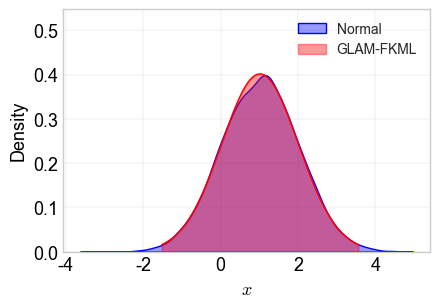

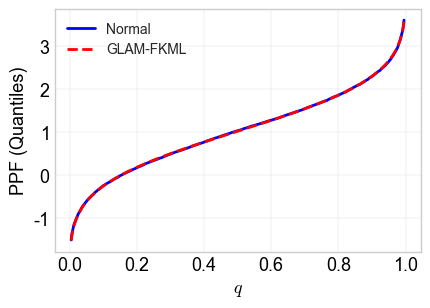

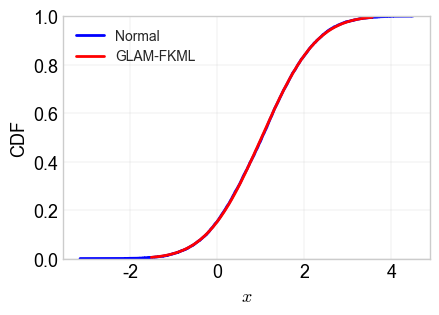

Gráficos da Normal salvos com sucesso!



In [19]:
dados_normal = np.random.normal(1, 1, 10000)

g = GlamFKML()
sol = g.fit_lambdas(dados_normal, method="least_squares")

print(f"Lambdas: L1={sol.x[0]:.4f} | L2={sol.x[1]:.4f} | L3={sol.x[2]:.4f} | L4={sol.x[3]:.4f}")

# Lambdas do modelo ajustado
modelo_ajustado = GlamFKML(*sol.x)
salvar_graficos_glam(dados_normal, modelo_ajustado, 'Normal')
print("Gráficos da Normal salvos com sucesso!\n")

# Distribuição Gumbel

Lambdas: L1=1.2629 | L2=1.1479 | L3=0.4894 | L4=-0.0196


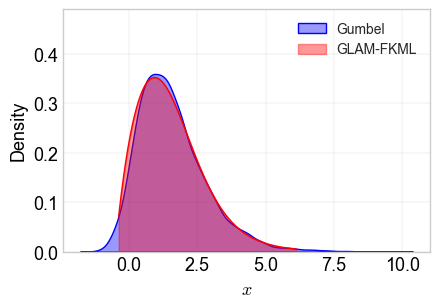

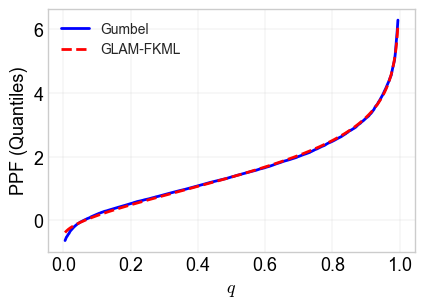

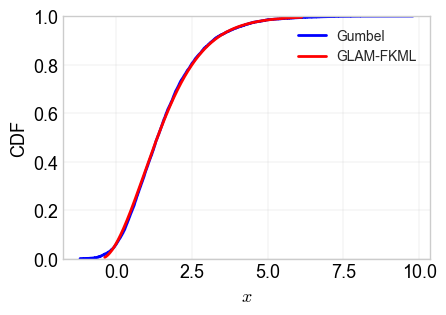

Gráficos da Gumbel salvos com sucesso!



In [18]:
dados_gumbel = np.random.gumbel(1, 1, 10000)

g = GlamFKML()
sol = g.fit_lambdas(dados_gumbel, method="least_squares")

print(f"Lambdas: L1={sol.x[0]:.4f} | L2={sol.x[1]:.4f} | L3={sol.x[2]:.4f} | L4={sol.x[3]:.4f}")

modelo_ajustado = GlamFKML(*sol.x)
salvar_graficos_glam(dados_gumbel, modelo_ajustado, 'Gumbel')
print("Gráficos da Gumbel salvos com sucesso!\n")

# Distribuição Log-Normal

Lambdas: L1=1.0187 | L2=0.7393 | L3=27.3379 | L4=-0.1965


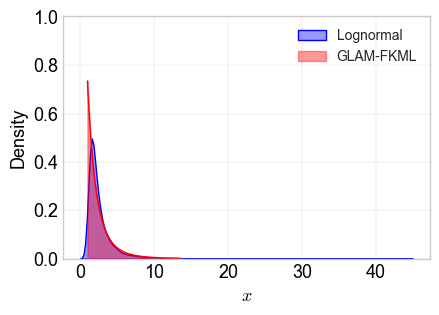

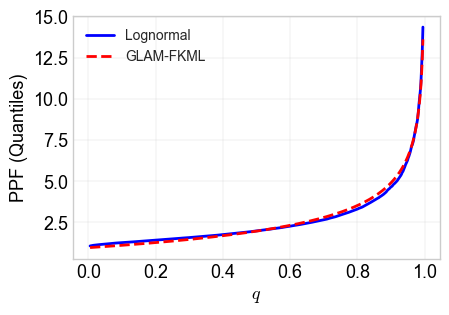

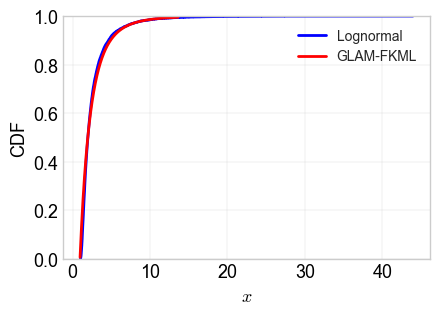

Gráficos da Log-normal salvos com sucesso!



In [20]:
dados_lognorm = np.random.lognormal(mean=0, sigma=1, size=10000) + 1

g = GlamFKML()
sol = g.fit_lambdas(dados_lognorm, method="least_squares")

print(f"Lambdas: L1={sol.x[0]:.4f} | L2={sol.x[1]:.4f} | L3={sol.x[2]:.4f} | L4={sol.x[3]:.4f}")

modelo_ajustado = GlamFKML(*sol.x)
salvar_graficos_glam(dados_lognorm, modelo_ajustado, 'Lognormal')
print("Gráficos da Log-normal salvos com sucesso!\n")

# Distribuição Triangular

Lambdas: L1=1.0042 | L2=2.8390 | L3=0.3019 | L4=0.3167


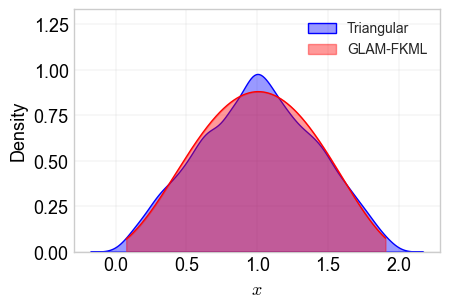

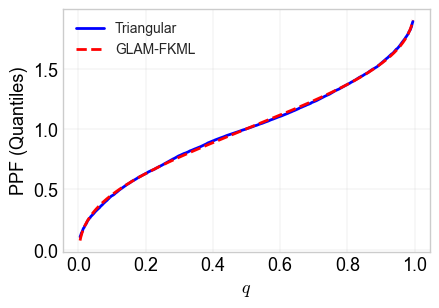

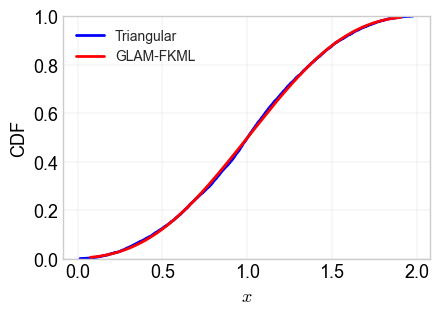

Gráficos da Triangular salvos com sucesso!



In [21]:
dados_triang = np.random.triangular(0, 1, 2, 10000)

g = GlamFKML()
sol = g.fit_lambdas(dados_triang, method="least_squares")

print(f"Lambdas: L1={sol.x[0]:.4f} | L2={sol.x[1]:.4f} | L3={sol.x[2]:.4f} | L4={sol.x[3]:.4f}")

modelo_ajustado = GlamFKML(*sol.x)
salvar_graficos_glam(dados_triang, modelo_ajustado, 'Triangular')
print("Gráficos da Triangular salvos com sucesso!\n")

# Distribuição Uniforme

Lambdas: L1=0.9980 | L2=0.9228 | L3=1.0925 | L4=1.0898


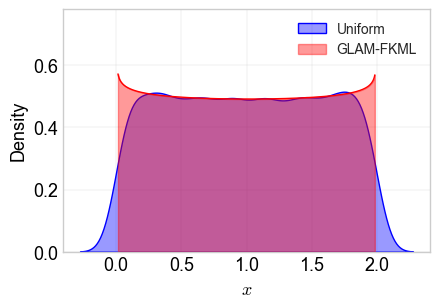

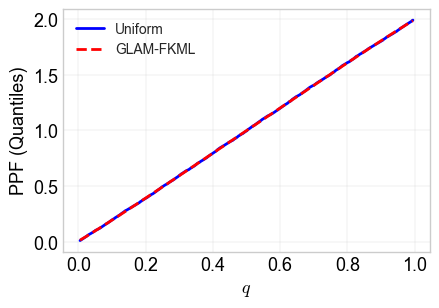

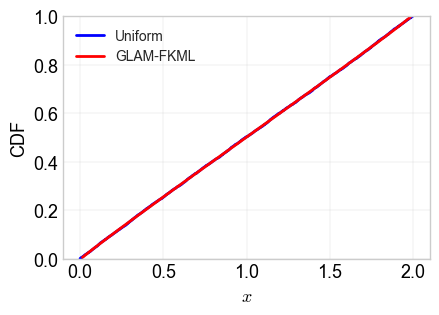

Gráficos da Uniforme salvos com sucesso!



In [22]:
dados_unif = np.random.uniform(0, 2, 10000)

g = GlamFKML()
sol = g.fit_lambdas(dados_unif, method="least_squares")

print(f"Lambdas: L1={sol.x[0]:.4f} | L2={sol.x[1]:.4f} | L3={sol.x[2]:.4f} | L4={sol.x[3]:.4f}")

modelo_ajustado = GlamFKML(*sol.x)
salvar_graficos_glam(dados_unif, modelo_ajustado, 'Uniform')
print("Gráficos da Uniforme salvos com sucesso!\n")